# Pong A2C CNN - WandB Training Analysis

This notebook analyzes all metrics logged to Weights & Biases during training.
The analysis is organized into sections mirroring the wandb dashboard:

1. **Model Info** - Architecture statistics
2. **Training** - Episode rewards and learning progress
3. **Losses** - Policy, value, entropy, and total loss
4. **Gradient Norms** - Layer-wise gradient magnitudes
5. **Weight Stats** - Weight distribution evolution
6. **System** - Training updates and efficiency

In [1]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
from dotenv import load_dotenv

# Setup
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11

# Load wandb credentials
RL_STUDY_DIR = Path.cwd().parent.parent if Path.cwd().name == 'pong_a2c_cnn' else Path.cwd()
load_dotenv(RL_STUDY_DIR / '.env')
wandb_key = os.getenv('WANDB_KEY')
wandb.login(key=wandb_key)

print("Setup complete!")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/bmartins/.netrc
wandb: Currently logged in as: bmartins to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Setup complete!


In [2]:
# Fetch run data from wandb
api = wandb.Api()

# Get the most recent run from the project
# Update entity/project as needed
runs = api.runs("pong_rl_training", filters={"config.architecture": "CNN-A2C-Basic"})

if len(runs) == 0:
    print("No runs found. Trying without filter...")
    runs = api.runs("pong_rl_training")

run = runs[0]  # Most recent run
print(f"Analyzing run: {run.name}")
print(f"Run ID: {run.id}")
print(f"State: {run.state}")

# Fetch all history data
history = run.scan_history()
df = pd.DataFrame(history)

print(f"\nTotal logged steps: {len(df)}")
print(f"Columns available: {len(df.columns)}")

Analyzing run: pong_cnn_a2c_basic
Run ID: agf09nnf
State: finished

Total logged steps: 11129
Columns available: 138


In [3]:
# List all available metrics grouped by section
columns = df.columns.tolist()

sections = {
    'model_info': [c for c in columns if c.startswith('model_info/')],
    'training': [c for c in columns if c.startswith('training/')],
    'losses': [c for c in columns if c.startswith('losses/')],
    'grad_norms': [c for c in columns if c.startswith('grad_norms/')],
    'weight_stats': [c for c in columns if c.startswith('weight_stats/')],
    'system': [c for c in columns if c.startswith('system/')],
    'other': [c for c in columns if not any(c.startswith(p) for p in ['model_info/', 'training/', 'losses/', 'grad_norms/', 'weight_stats/', 'system/', '_'])]
}

for section, cols in sections.items():
    if cols:
        print(f"\n{section.upper()} ({len(cols)} metrics):")
        for col in sorted(cols):
            print(f"  - {col}")


MODEL_INFO (9 metrics):
  - model_info/actor_parameters
  - model_info/actor_percentage
  - model_info/conv_parameters
  - model_info/conv_percentage
  - model_info/critic_parameters
  - model_info/critic_percentage
  - model_info/model_size_mb
  - model_info/total_parameters
  - model_info/trainable_parameters

TRAINING (4 metrics):
  - training/episode
  - training/episode_length
  - training/episode_reward
  - training/mean_reward_100

LOSSES (4 metrics):
  - losses/entropy_loss
  - losses/policy_loss
  - losses/total_loss
  - losses/value_loss

GRAD_NORMS (14 metrics):
  - grad_norms/actor_fc.bias
  - grad_norms/actor_fc.weight
  - grad_norms/conv.0.bias
  - grad_norms/conv.0.weight
  - grad_norms/conv.2.bias
  - grad_norms/conv.2.weight
  - grad_norms/conv.4.bias
  - grad_norms/conv.4.weight
  - grad_norms/critic_fc.bias
  - grad_norms/critic_fc.weight
  - grad_norms/policy_head.bias
  - grad_norms/policy_head.weight
  - grad_norms/value_head.bias
  - grad_norms/value_head.weight

---
## 1. Model Info

Architecture statistics logged at initialization.

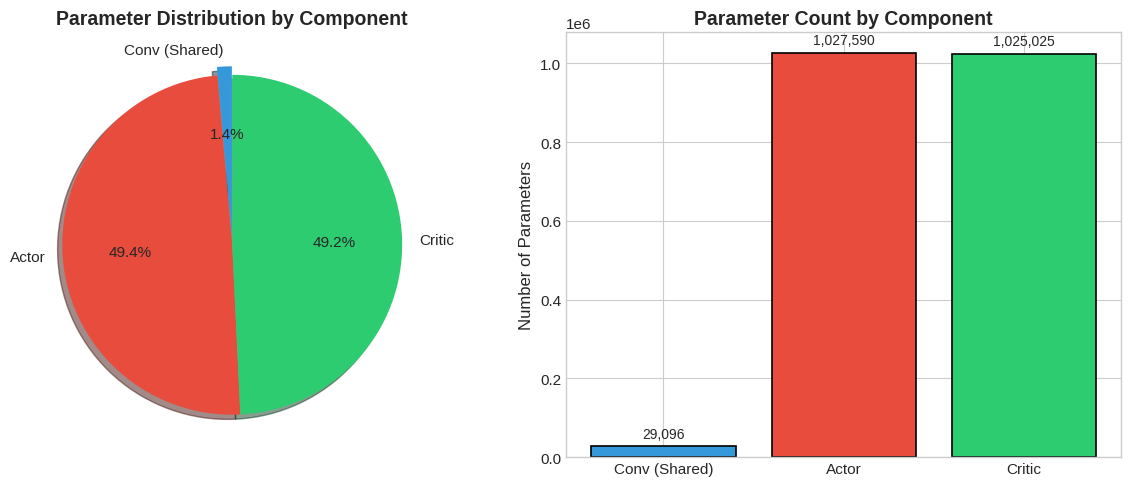

Total parameters: 2,081,711
Model size: 7.94 MB


In [4]:
# Model Parameters Distribution
model_info_cols = [c for c in df.columns if c.startswith('model_info/')]

if model_info_cols:
    # Get model info from first row (logged at step 0)
    model_info = df[model_info_cols].dropna().iloc[0] if len(df[model_info_cols].dropna()) > 0 else None
    
    if model_info is not None:
        # Parameter counts
        param_cols = ['model_info/conv_parameters', 'model_info/actor_parameters', 'model_info/critic_parameters']
        available_param_cols = [c for c in param_cols if c in model_info.index]
        
        if available_param_cols:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
            
            # Pie chart of parameter distribution
            labels = ['Conv (Shared)', 'Actor', 'Critic']
            sizes = [model_info.get('model_info/conv_parameters', 0),
                     model_info.get('model_info/actor_parameters', 0),
                     model_info.get('model_info/critic_parameters', 0)]
            colors = ['#3498db', '#e74c3c', '#2ecc71']
            explode = (0.05, 0, 0)
            
            ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
                    shadow=True, startangle=90)
            ax1.set_title('Parameter Distribution by Component', fontsize=14, fontweight='bold')
            
            # Bar chart of parameter counts
            ax2.bar(labels, sizes, color=colors, edgecolor='black', linewidth=1.2)
            ax2.set_ylabel('Number of Parameters', fontsize=12)
            ax2.set_title('Parameter Count by Component', fontsize=14, fontweight='bold')
            ax2.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
            
            for i, v in enumerate(sizes):
                ax2.text(i, v + max(sizes)*0.02, f'{int(v):,}', ha='center', fontsize=10)
            
            plt.tight_layout()
            plt.show()
            
            print(f"Total parameters: {model_info.get('model_info/total_parameters', 'N/A'):,.0f}")
            print(f"Model size: {model_info.get('model_info/model_size_mb', 'N/A'):.2f} MB")
else:
    print("No model_info metrics found in this run.")

**Observation:** The A2C architecture uses a shared CNN backbone (small fraction of total params) with separate actor and critic heads that each contain roughly half the parameters. The shared features allow efficient learning while maintaining separate policy and value function representations.

---
## 2. Training

Episode rewards, mean performance, and learning progress over time.

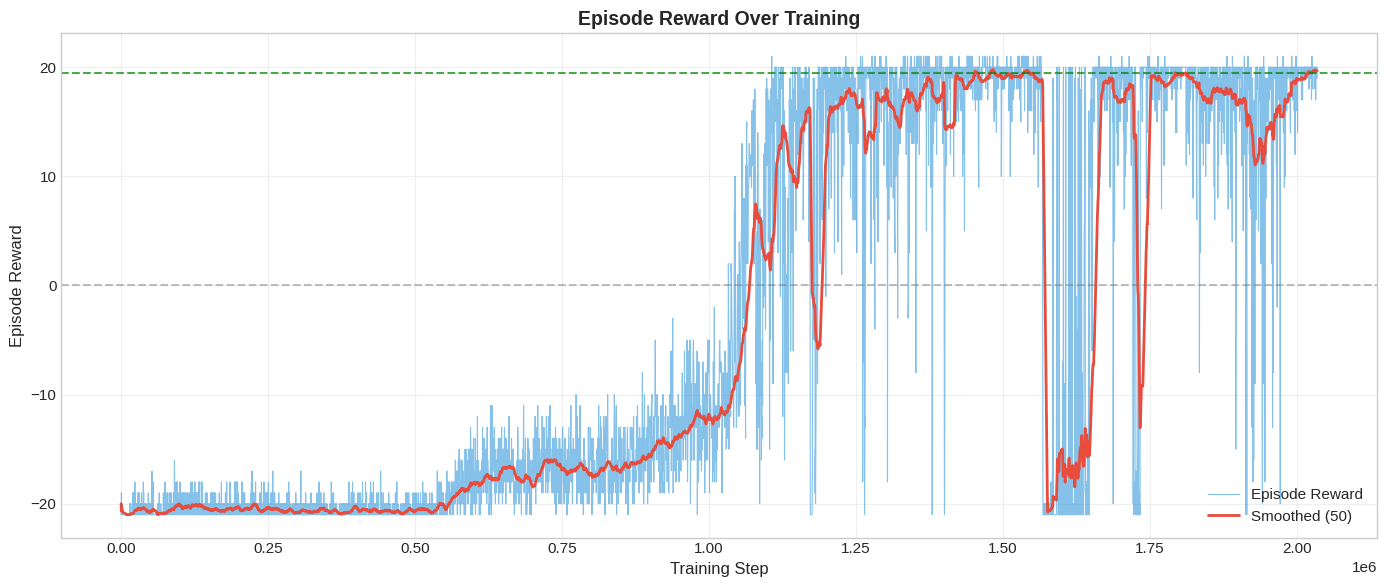

In [5]:
# Episode Reward Over Time
if 'training/episode_reward' in df.columns:
    reward_data = df[['_step', 'training/episode_reward']].dropna()
    
    plt.figure(figsize=(14, 6))
    plt.plot(reward_data['_step'], reward_data['training/episode_reward'], 
             alpha=0.6, linewidth=0.8, color='#3498db', label='Episode Reward')
    
    # Add smoothed line
    if len(reward_data) > 50:
        smoothed = reward_data['training/episode_reward'].rolling(window=50, min_periods=1).mean()
        plt.plot(reward_data['_step'], smoothed, color='#e74c3c', linewidth=2, label='Smoothed (50)')
    
    plt.xlabel('Training Step', fontsize=12)
    plt.ylabel('Episode Reward', fontsize=12)
    plt.title('Episode Reward Over Training', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right')
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.axhline(y=19.5, color='green', linestyle='--', alpha=0.7, label='Target (19.5)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("training/episode_reward not found in data.")

**Observation:** Episode rewards show high variance initially as the agent explores randomly. The upward trend indicates successful learning, with rewards improving from strongly negative (losing badly) toward positive values (winning). The variance decreases as the policy becomes more deterministic and skilled.

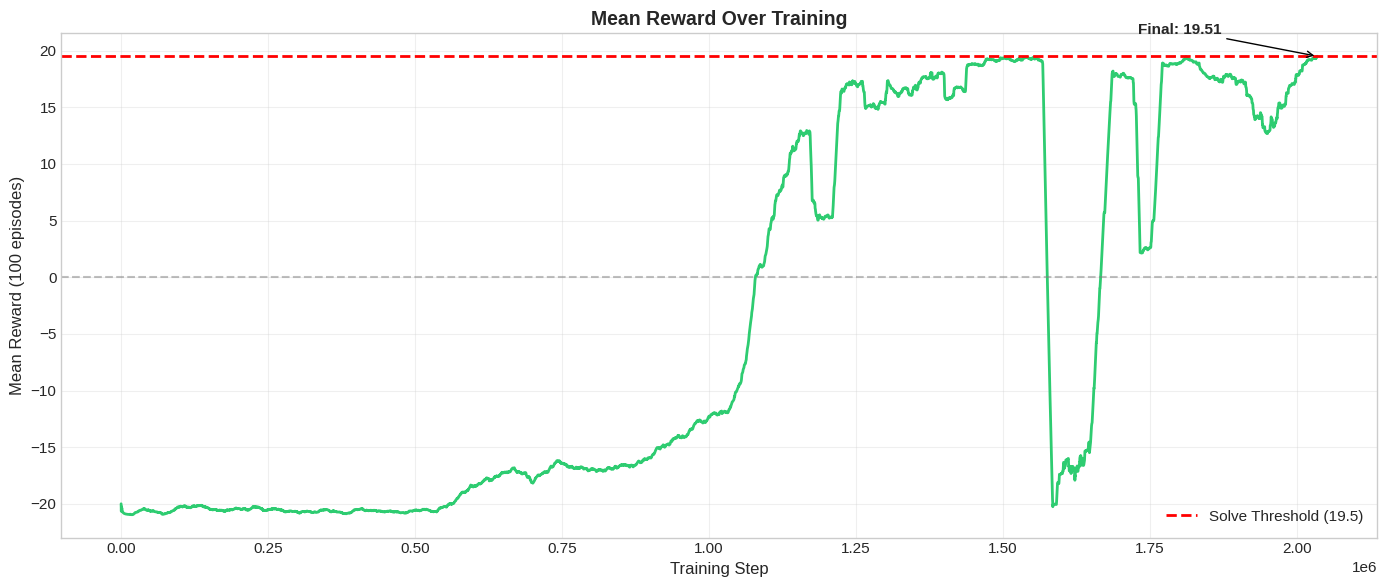

In [6]:
# Mean Reward (100 episodes) - Primary Success Metric
if 'training/mean_reward_100' in df.columns:
    mean_data = df[['_step', 'training/mean_reward_100']].dropna()
    
    plt.figure(figsize=(14, 6))
    plt.plot(mean_data['_step'], mean_data['training/mean_reward_100'], 
             linewidth=2, color='#2ecc71')
    
    plt.axhline(y=19.5, color='red', linestyle='--', linewidth=2, label='Solve Threshold (19.5)')
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    
    plt.xlabel('Training Step', fontsize=12)
    plt.ylabel('Mean Reward (100 episodes)', fontsize=12)
    plt.title('Mean Reward Over Training', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    
    # Annotate final value
    final_reward = mean_data['training/mean_reward_100'].iloc[-1]
    plt.annotate(f'Final: {final_reward:.2f}', 
                 xy=(mean_data['_step'].iloc[-1], final_reward),
                 xytext=(mean_data['_step'].iloc[-1] * 0.85, final_reward + 2),
                 fontsize=11, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='black'))
    
    plt.tight_layout()
    plt.show()
else:
    print("training/mean_reward_100 not found in data.")

**Observation:** The mean reward (100-episode rolling average) is the primary metric for evaluating learning progress. A consistent upward trajectory indicates stable learning. Plateaus may indicate the agent has reached a local optimum or needs more exploration. The target of 19.5 represents near-perfect play against the built-in AI.

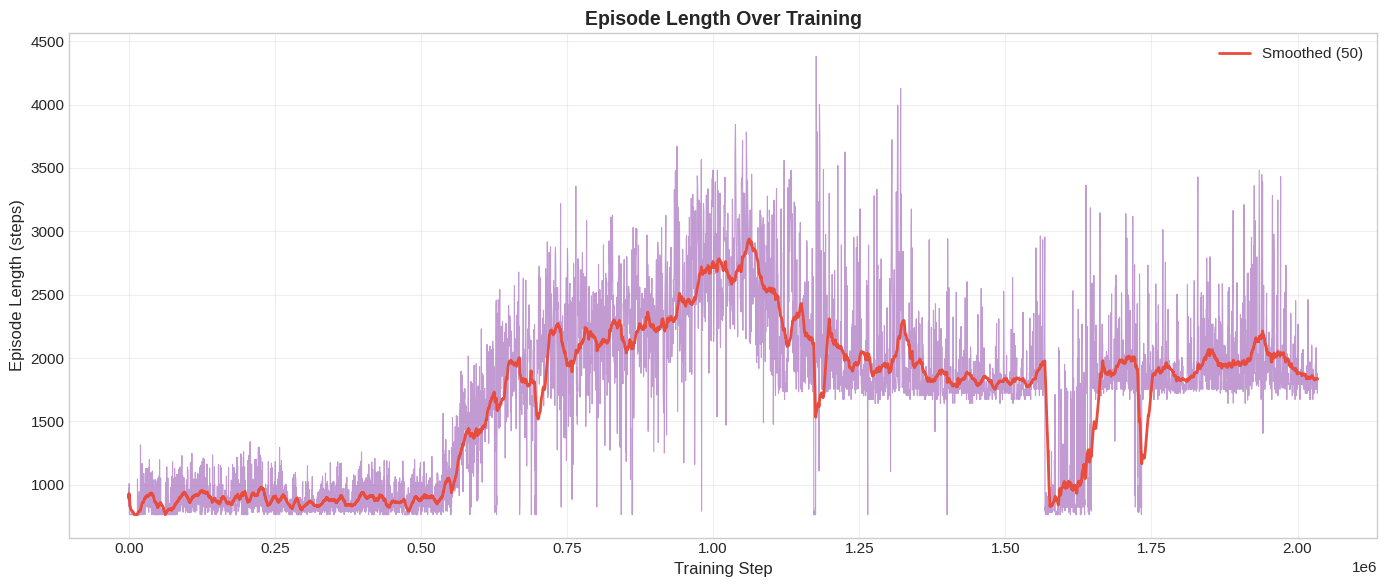

In [7]:
# Episode Length Over Time
if 'training/episode_length' in df.columns:
    length_data = df[['_step', 'training/episode_length']].dropna()
    
    plt.figure(figsize=(14, 6))
    plt.plot(length_data['_step'], length_data['training/episode_length'], 
             alpha=0.6, linewidth=0.8, color='#9b59b6')
    
    # Add smoothed line
    if len(length_data) > 50:
        smoothed = length_data['training/episode_length'].rolling(window=50, min_periods=1).mean()
        plt.plot(length_data['_step'], smoothed, color='#e74c3c', linewidth=2, label='Smoothed (50)')
    
    plt.xlabel('Training Step', fontsize=12)
    plt.ylabel('Episode Length (steps)', fontsize=12)
    plt.title('Episode Length Over Training', fontsize=14, fontweight='bold')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("training/episode_length not found in data.")

**Observation:** Episode length reflects game duration. In Pong, shorter episodes when losing (opponent scores quickly) vs longer episodes as skill improves (more rallies). A skilled agent should show moderate, consistent episode lengths as games become competitive rather than one-sided.

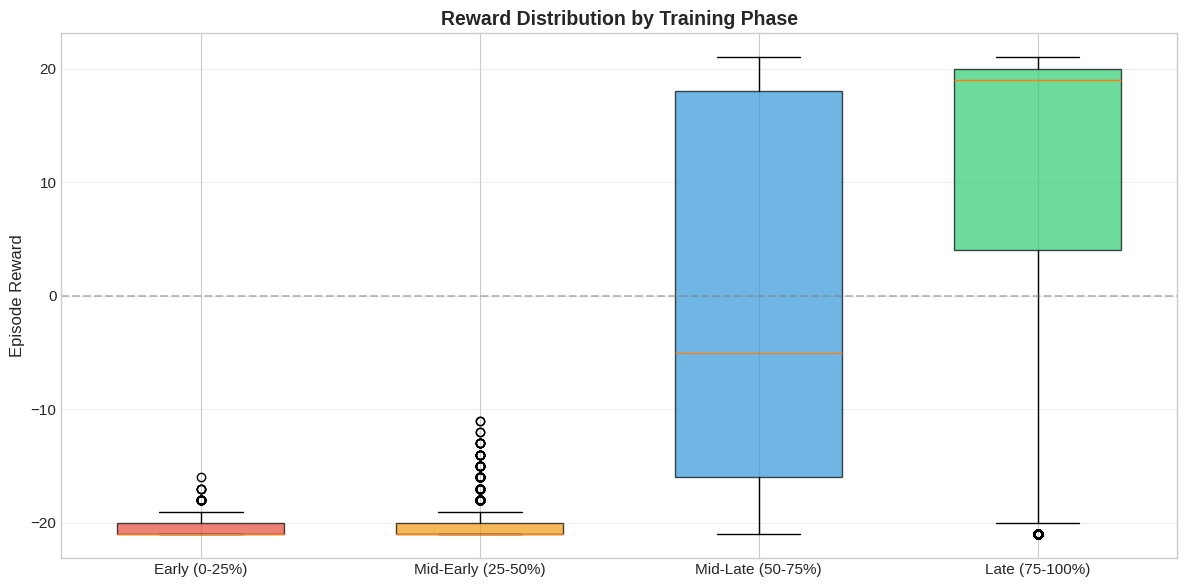

Phase Statistics:
  Early (0-25%): mean=-20.54, std=0.71, median=-21.00
  Mid-Early (25-50%): mean=-20.05, std=1.55, median=-21.00
  Mid-Late (50-75%): mean=0.26, std=16.33, median=-5.00
  Late (75-100%): mean=9.11, std=16.66, median=19.00


In [8]:
# Reward Distribution Over Training Phases
if 'training/episode_reward' in df.columns:
    reward_data = df[['_step', 'training/episode_reward']].dropna()
    
    # Split into phases
    n = len(reward_data)
    phases = {
        'Early (0-25%)': reward_data.iloc[:n//4]['training/episode_reward'],
        'Mid-Early (25-50%)': reward_data.iloc[n//4:n//2]['training/episode_reward'],
        'Mid-Late (50-75%)': reward_data.iloc[n//2:3*n//4]['training/episode_reward'],
        'Late (75-100%)': reward_data.iloc[3*n//4:]['training/episode_reward']
    }
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
    positions = list(range(len(phases)))
    
    bp = ax.boxplot([phases[k] for k in phases.keys()], positions=positions, 
                    patch_artist=True, widths=0.6)
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_xticklabels(phases.keys(), fontsize=11)
    ax.set_ylabel('Episode Reward', fontsize=12)
    ax.set_title('Reward Distribution by Training Phase', fontsize=14, fontweight='bold')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("Phase Statistics:")
    for phase, data in phases.items():
        print(f"  {phase}: mean={data.mean():.2f}, std={data.std():.2f}, median={data.median():.2f}")
else:
    print("training/episode_reward not found in data.")

**Observation:** The box plots reveal how reward distribution shifts during training. Early phases show wide variance with many negative rewards (losses). As training progresses, the distribution should shift upward with the median increasing and variance potentially decreasing as the policy stabilizes.

---
## 3. Losses

A2C loss components: policy loss, value loss, entropy loss, and total loss.

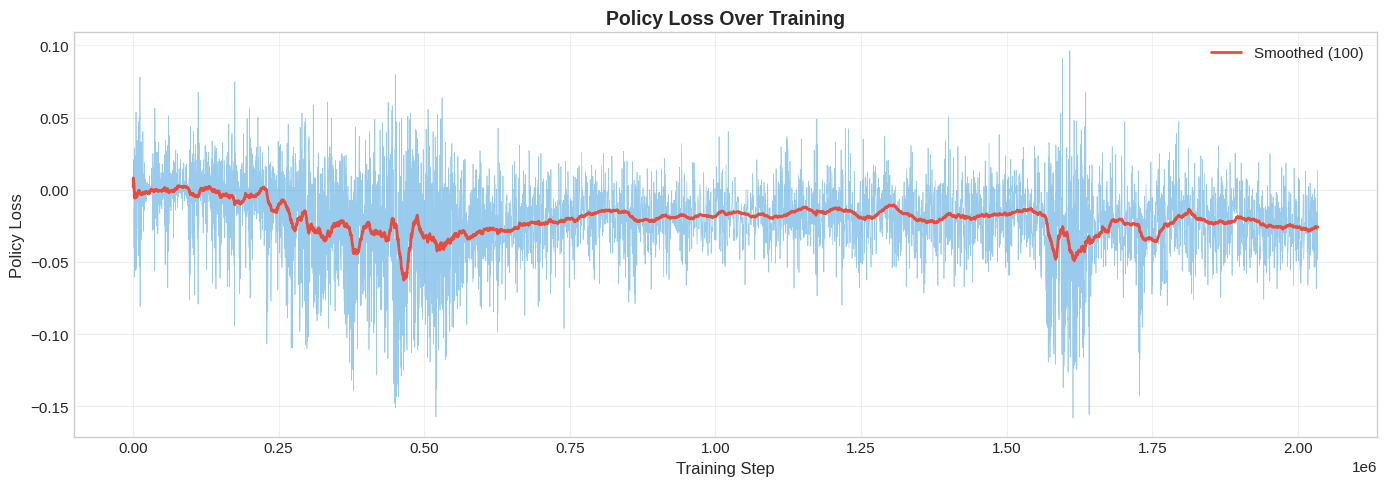

In [9]:
# Policy Loss
if 'losses/policy_loss' in df.columns:
    loss_data = df[['_step', 'losses/policy_loss']].dropna()
    
    plt.figure(figsize=(14, 5))
    plt.plot(loss_data['_step'], loss_data['losses/policy_loss'], 
             alpha=0.5, linewidth=0.5, color='#3498db')
    
    # Smoothed version
    if len(loss_data) > 100:
        smoothed = loss_data['losses/policy_loss'].rolling(window=100, min_periods=1).mean()
        plt.plot(loss_data['_step'], smoothed, color='#e74c3c', linewidth=2, label='Smoothed (100)')
    
    plt.xlabel('Training Step', fontsize=12)
    plt.ylabel('Policy Loss', fontsize=12)
    plt.title('Policy Loss Over Training', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("losses/policy_loss not found in data.")

**Observation:** Policy loss represents the negative log-likelihood of actions weighted by advantages. It should fluctuate as the policy adapts. Large spikes indicate high-advantage actions being reinforced. The loss doesn't necessarily decrease monotonically - a changing policy naturally produces varying loss values.

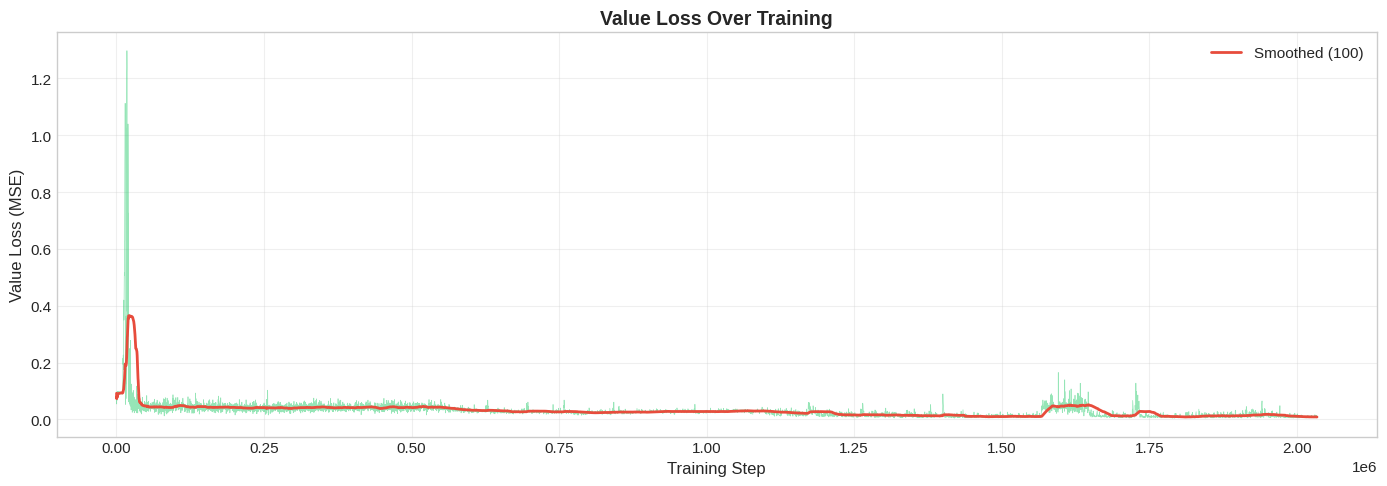

In [10]:
# Value Loss
if 'losses/value_loss' in df.columns:
    loss_data = df[['_step', 'losses/value_loss']].dropna()
    
    plt.figure(figsize=(14, 5))
    plt.plot(loss_data['_step'], loss_data['losses/value_loss'], 
             alpha=0.5, linewidth=0.5, color='#2ecc71')
    
    # Smoothed version
    if len(loss_data) > 100:
        smoothed = loss_data['losses/value_loss'].rolling(window=100, min_periods=1).mean()
        plt.plot(loss_data['_step'], smoothed, color='#e74c3c', linewidth=2, label='Smoothed (100)')
    
    plt.xlabel('Training Step', fontsize=12)
    plt.ylabel('Value Loss (MSE)', fontsize=12)
    plt.title('Value Loss Over Training', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("losses/value_loss not found in data.")

**Observation:** Value loss (MSE between predicted and actual returns) should generally decrease as the critic learns to predict future rewards more accurately. High value loss early on is expected as the value function is randomly initialized. Persistent high loss may indicate the critic is struggling to model the reward landscape.

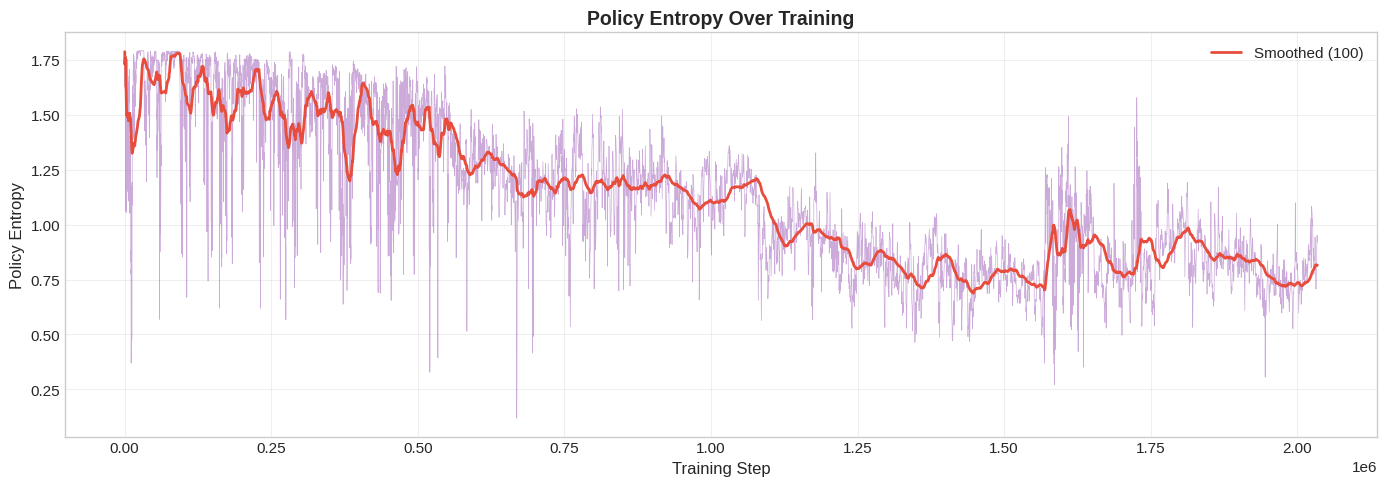

In [11]:
# Entropy Loss (negative entropy for minimization)
if 'losses/entropy_loss' in df.columns:
    loss_data = df[['_step', 'losses/entropy_loss']].dropna()
    
    plt.figure(figsize=(14, 5))
    
    # Plot negative of entropy_loss to show actual entropy
    entropy_values = -loss_data['losses/entropy_loss']  # Convert back to positive entropy
    
    plt.plot(loss_data['_step'], entropy_values, 
             alpha=0.5, linewidth=0.5, color='#9b59b6')
    
    # Smoothed version
    if len(loss_data) > 100:
        smoothed = entropy_values.rolling(window=100, min_periods=1).mean()
        plt.plot(loss_data['_step'], smoothed, color='#e74c3c', linewidth=2, label='Smoothed (100)')
    
    plt.xlabel('Training Step', fontsize=12)
    plt.ylabel('Policy Entropy', fontsize=12)
    plt.title('Policy Entropy Over Training', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("losses/entropy_loss not found in data.")

**Observation:** Policy entropy measures exploration vs exploitation. High entropy = uniform action distribution (maximum exploration). Entropy should decrease during training as the policy becomes more confident, but not collapse to zero (premature convergence). The entropy coefficient in A2C encourages maintaining some exploration throughout training.

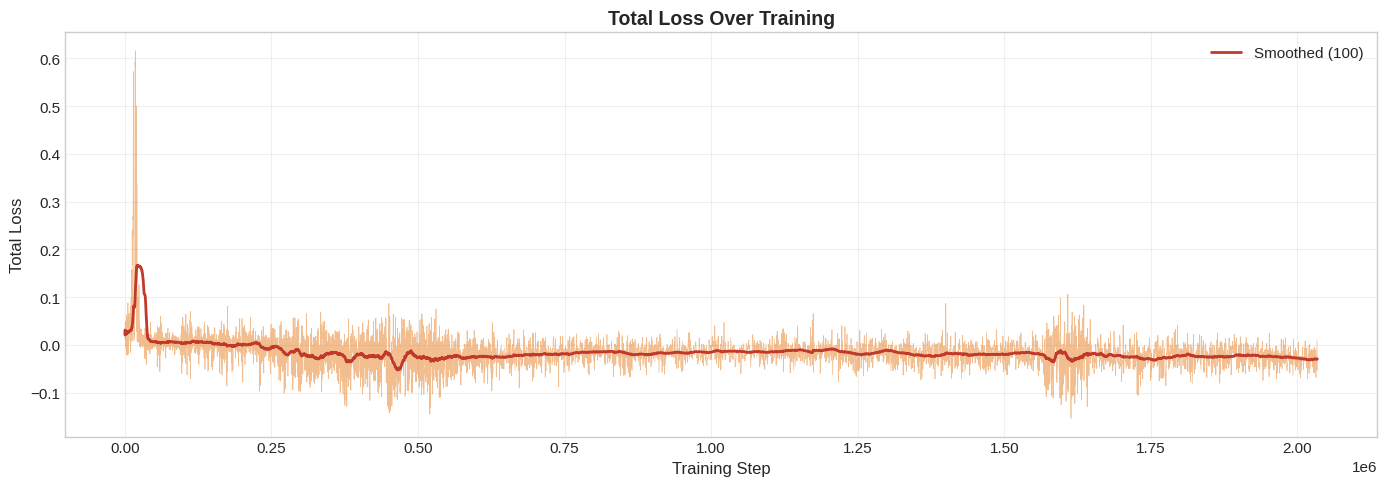

In [12]:
# Total Loss
if 'losses/total_loss' in df.columns:
    loss_data = df[['_step', 'losses/total_loss']].dropna()
    
    plt.figure(figsize=(14, 5))
    plt.plot(loss_data['_step'], loss_data['losses/total_loss'], 
             alpha=0.5, linewidth=0.5, color='#e67e22')
    
    # Smoothed version
    if len(loss_data) > 100:
        smoothed = loss_data['losses/total_loss'].rolling(window=100, min_periods=1).mean()
        plt.plot(loss_data['_step'], smoothed, color='#c0392b', linewidth=2, label='Smoothed (100)')
    
    plt.xlabel('Training Step', fontsize=12)
    plt.ylabel('Total Loss', fontsize=12)
    plt.title('Total Loss Over Training', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("losses/total_loss not found in data.")

**Observation:** Total loss combines policy loss, value loss (weighted by value_loss_coef), and entropy loss (weighted by entropy_coef). The combined loss should show an overall downward trend, though fluctuations are normal. Large spikes may indicate unstable updates or encountering novel game situations.

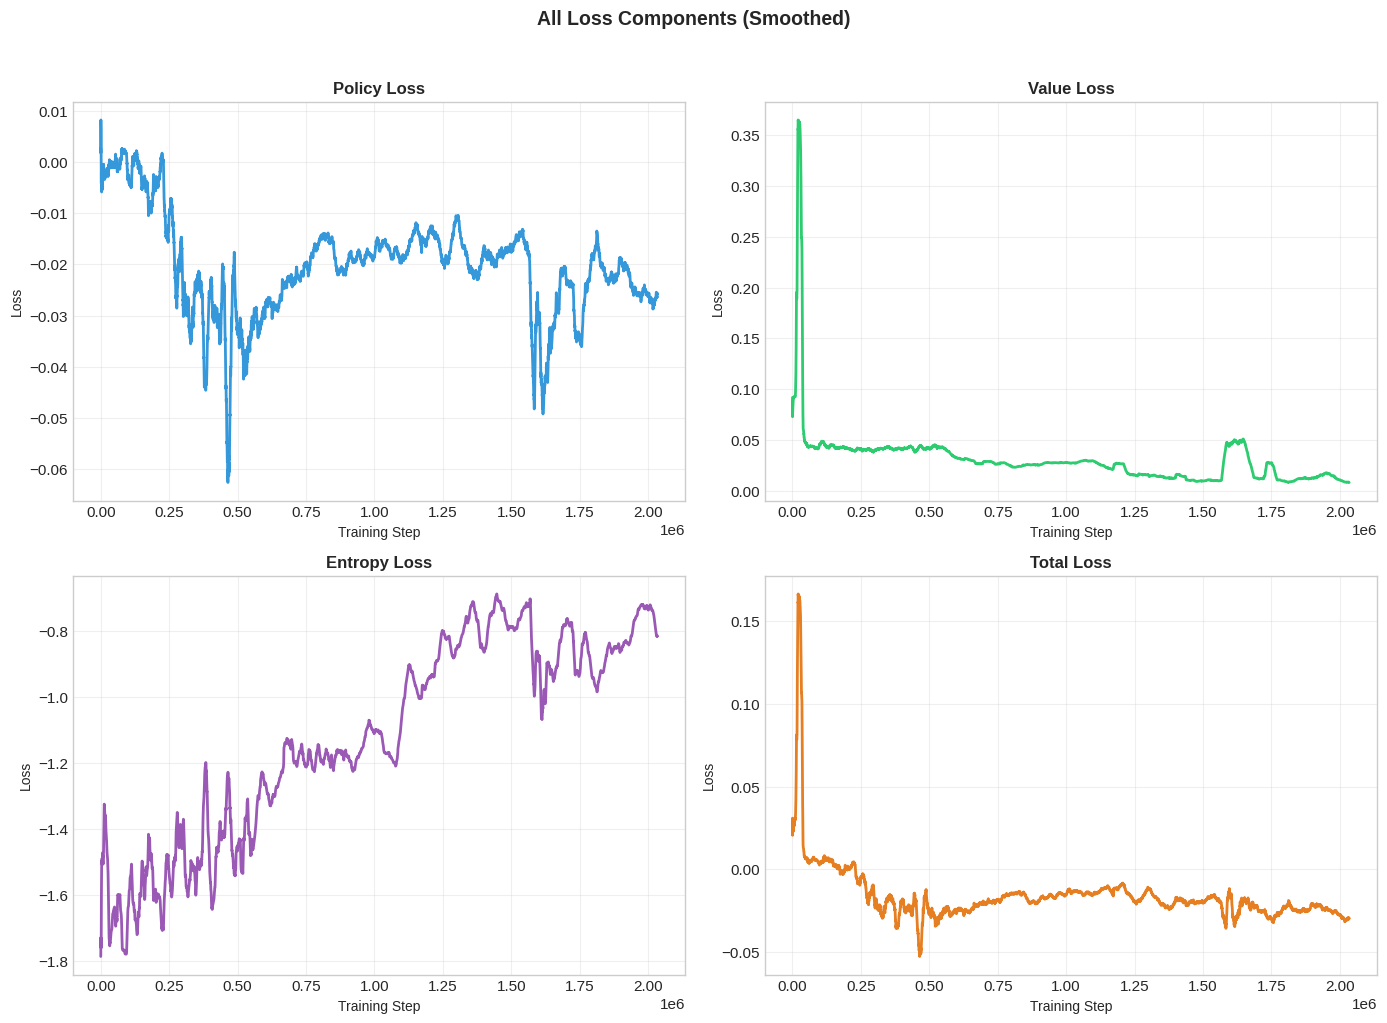

In [13]:
# All Losses Combined (Smoothed)
loss_cols = ['losses/policy_loss', 'losses/value_loss', 'losses/entropy_loss', 'losses/total_loss']
available_loss_cols = [c for c in loss_cols if c in df.columns]

if available_loss_cols:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    colors = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22']
    titles = ['Policy Loss', 'Value Loss', 'Entropy Loss', 'Total Loss']
    
    for idx, (col, color, title) in enumerate(zip(loss_cols, colors, titles)):
        if col in df.columns:
            data = df[['_step', col]].dropna()
            
            if len(data) > 100:
                smoothed = data[col].rolling(window=100, min_periods=1).mean()
                axes[idx].plot(data['_step'], smoothed, color=color, linewidth=2)
            else:
                axes[idx].plot(data['_step'], data[col], color=color, linewidth=1)
            
            axes[idx].set_xlabel('Training Step', fontsize=10)
            axes[idx].set_ylabel('Loss', fontsize=10)
            axes[idx].set_title(title, fontsize=12, fontweight='bold')
            axes[idx].grid(True, alpha=0.3)
    
    plt.suptitle('All Loss Components (Smoothed)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No loss metrics found in data.")

**Observation:** Viewing all losses together reveals correlations. Policy and value losses often move together as both depend on the quality of state representations. A well-balanced training should show all components contributing without any single loss dominating or collapsing.

---
## 4. Gradient Norms

Layer-wise gradient magnitudes during backpropagation.

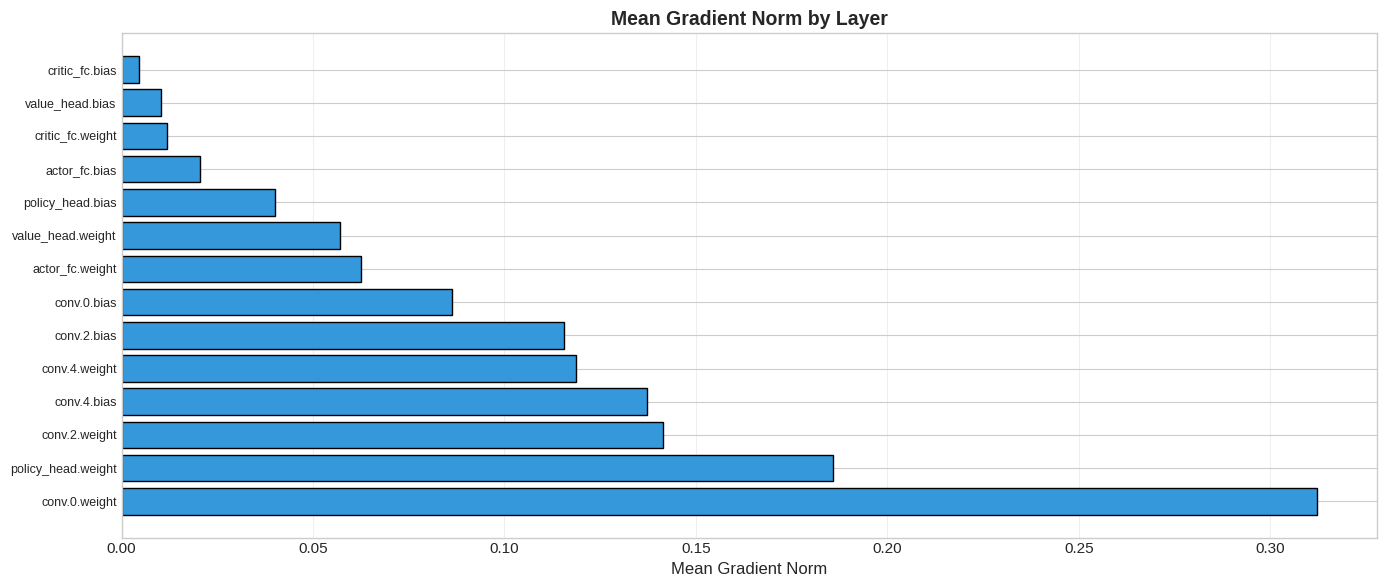

In [14]:
# Gradient Norms Overview
grad_cols = [c for c in df.columns if c.startswith('grad_norms/')]

if grad_cols:
    # Get mean gradient norm per layer
    grad_data = df[grad_cols].dropna()
    
    if len(grad_data) > 0:
        mean_grads = grad_data.mean().sort_values(ascending=False)
        
        plt.figure(figsize=(14, 6))
        
        # Clean up layer names for display
        layer_names = [c.replace('grad_norms/', '') for c in mean_grads.index]
        
        bars = plt.barh(range(len(mean_grads)), mean_grads.values, color='#3498db', edgecolor='black')
        plt.yticks(range(len(mean_grads)), layer_names, fontsize=9)
        plt.xlabel('Mean Gradient Norm', fontsize=12)
        plt.title('Mean Gradient Norm by Layer', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        plt.show()
    else:
        print("Gradient data available but all NaN.")
else:
    print("No grad_norms metrics found in data.")

**Observation:** Gradient norm distribution across layers reveals potential training issues. Very small gradients in early layers may indicate vanishing gradients. Very large gradients suggest exploding gradients. The output layers (actor/critic heads) typically have larger gradients than shared feature layers.

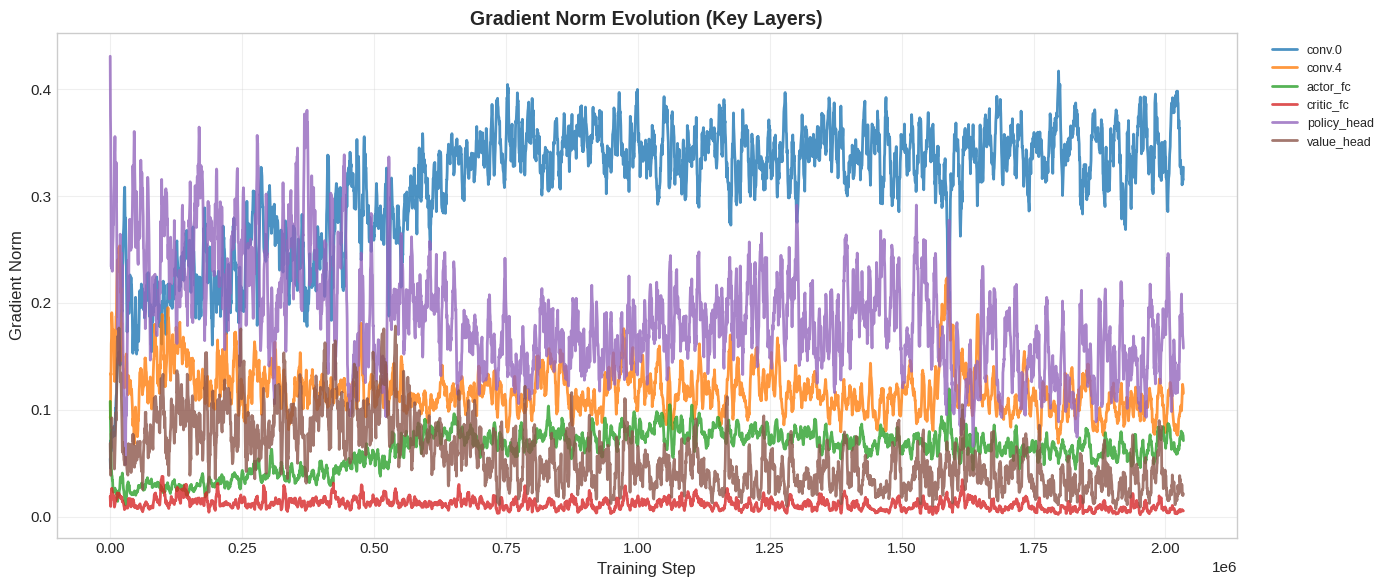

In [15]:
# Gradient Norm Evolution for Key Layers
grad_cols = [c for c in df.columns if c.startswith('grad_norms/')]

if grad_cols:
    # Select key layers to plot
    key_patterns = ['conv.0', 'conv.4', 'actor_fc', 'critic_fc', 'policy_head', 'value_head']
    key_cols = []
    
    for pattern in key_patterns:
        matching = [c for c in grad_cols if pattern in c and 'weight' in c]
        if matching:
            key_cols.append(matching[0])
    
    if key_cols:
        plt.figure(figsize=(14, 6))
        
        for col in key_cols:
            data = df[['_step', col]].dropna()
            if len(data) > 10:
                smoothed = data[col].rolling(window=10, min_periods=1).mean()
                label = col.replace('grad_norms/', '').replace('.weight', '')
                plt.plot(data['_step'], smoothed, linewidth=2, label=label, alpha=0.8)
        
        plt.xlabel('Training Step', fontsize=12)
        plt.ylabel('Gradient Norm', fontsize=12)
        plt.title('Gradient Norm Evolution (Key Layers)', fontsize=14, fontweight='bold')
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("No matching key layer gradients found.")
else:
    print("No grad_norms metrics found in data.")

**Observation:** Tracking gradient evolution over time shows training dynamics. Gradients should remain stable (not growing unboundedly or vanishing). Initial high variance that stabilizes indicates the network is adapting. Sudden spikes may correlate with encountering rare game situations.

---
## 5. Weight Statistics

Weight distribution evolution during training.

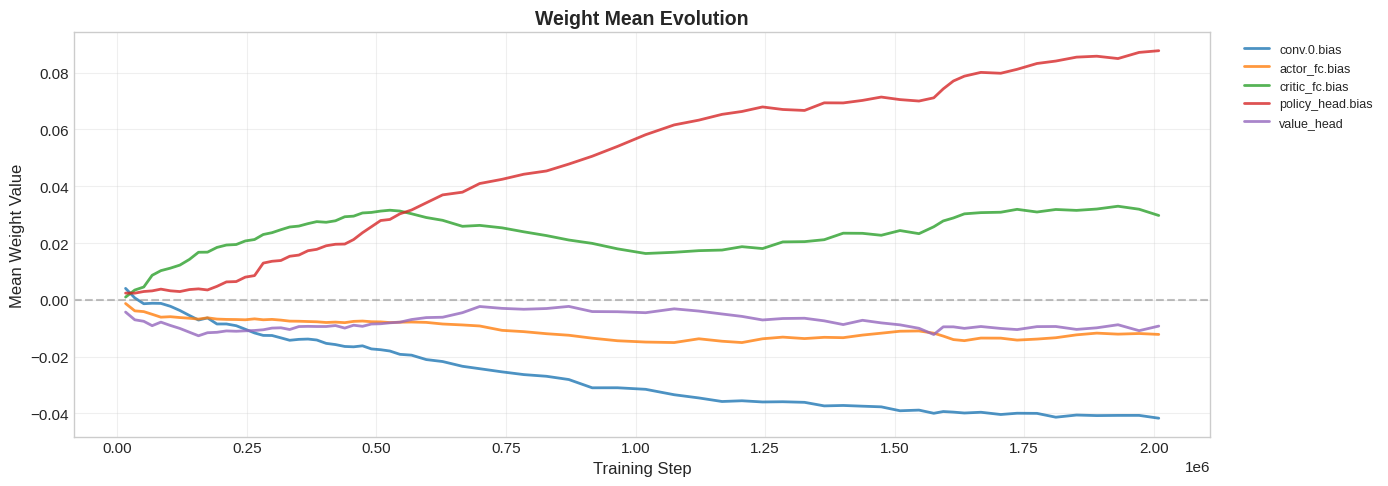

In [16]:
# Weight Mean Evolution
weight_mean_cols = [c for c in df.columns if c.startswith('weight_stats/') and '_mean' in c]

if weight_mean_cols:
    # Select key layers
    key_patterns = ['conv.0', 'actor_fc', 'critic_fc', 'policy_head', 'value_head']
    key_cols = []
    
    for pattern in key_patterns:
        matching = [c for c in weight_mean_cols if pattern in c]
        if matching:
            key_cols.append(matching[0])
    
    if key_cols:
        plt.figure(figsize=(14, 5))
        
        for col in key_cols:
            data = df[['_step', col]].dropna()
            if len(data) > 0:
                label = col.replace('weight_stats/', '').replace('.weight_mean', '').replace('_mean', '')
                plt.plot(data['_step'], data[col], linewidth=2, label=label, alpha=0.8)
        
        plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        plt.xlabel('Training Step', fontsize=12)
        plt.ylabel('Mean Weight Value', fontsize=12)
        plt.title('Weight Mean Evolution', fontsize=14, fontweight='bold')
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("No matching key layer weight means found.")
else:
    print("No weight_stats/*_mean metrics found in data.")

**Observation:** Weight means should remain centered near zero for properly normalized networks. Significant drift from zero may indicate issues with initialization or gradient flow. Actor and critic heads may drift as they specialize for their respective tasks.

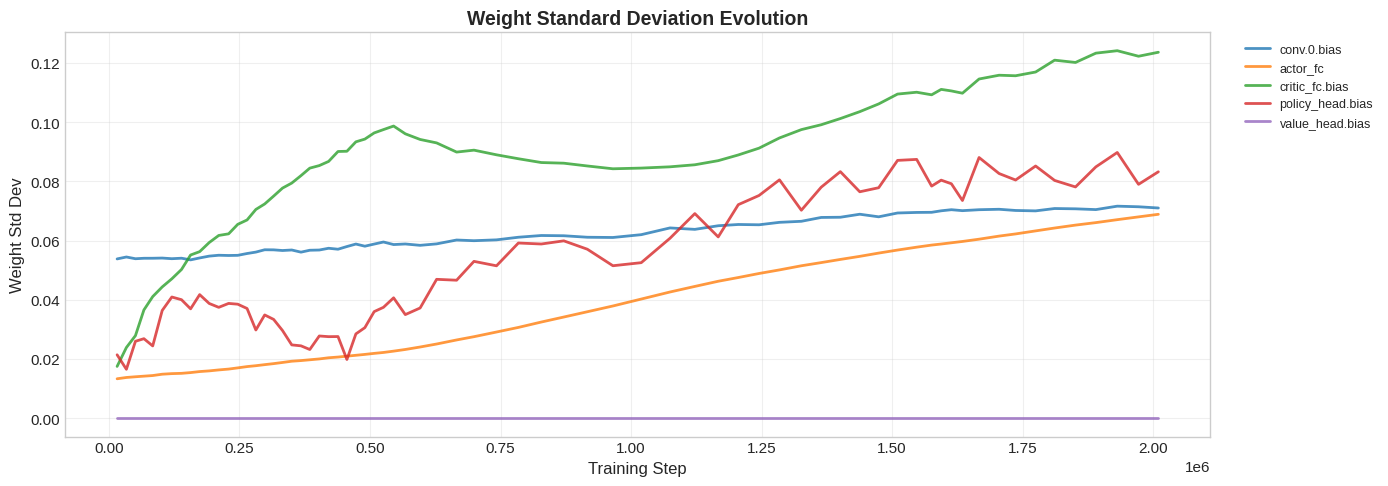

In [17]:
# Weight Standard Deviation Evolution
weight_std_cols = [c for c in df.columns if c.startswith('weight_stats/') and '_std' in c]

if weight_std_cols:
    # Select key layers
    key_patterns = ['conv.0', 'actor_fc', 'critic_fc', 'policy_head', 'value_head']
    key_cols = []
    
    for pattern in key_patterns:
        matching = [c for c in weight_std_cols if pattern in c]
        if matching:
            key_cols.append(matching[0])
    
    if key_cols:
        plt.figure(figsize=(14, 5))
        
        for col in key_cols:
            data = df[['_step', col]].dropna()
            if len(data) > 0:
                label = col.replace('weight_stats/', '').replace('.weight_std', '').replace('_std', '')
                plt.plot(data['_step'], data[col], linewidth=2, label=label, alpha=0.8)
        
        plt.xlabel('Training Step', fontsize=12)
        plt.ylabel('Weight Std Dev', fontsize=12)
        plt.title('Weight Standard Deviation Evolution', fontsize=14, fontweight='bold')
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("No matching key layer weight stds found.")
else:
    print("No weight_stats/*_std metrics found in data.")

**Observation:** Weight standard deviation indicates how spread out the weight values are. Increasing std may indicate growing weight magnitudes (potential issue). Stable or slightly decreasing std is typical for converging networks. Very small std may indicate dead neurons or collapsed representations.

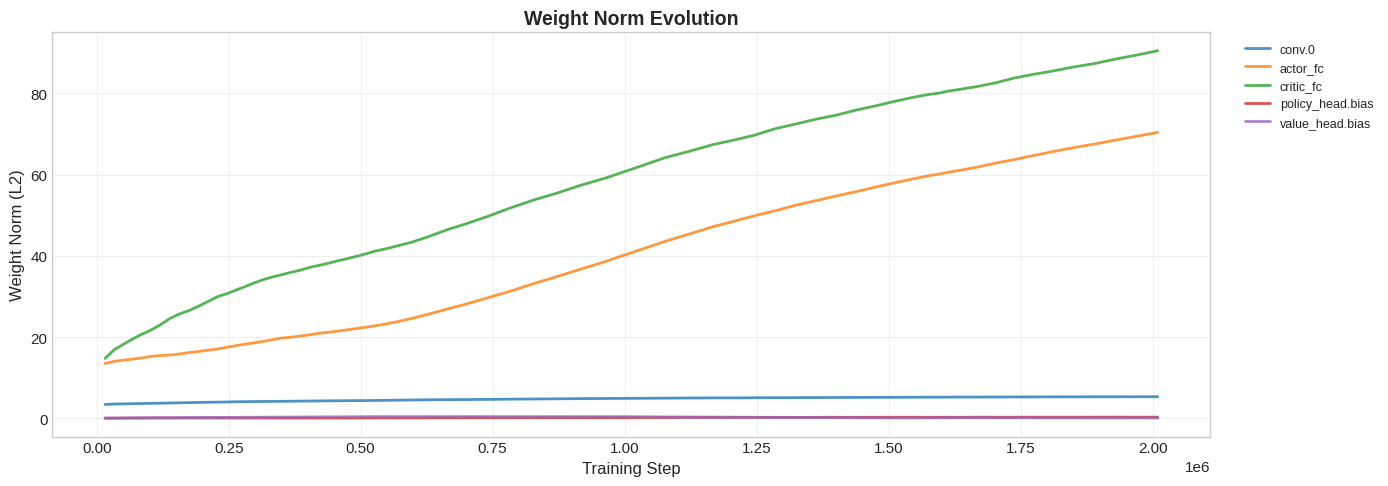

In [18]:
# Weight Norm Evolution
weight_norm_cols = [c for c in df.columns if c.startswith('weight_stats/') and '_norm' in c]

if weight_norm_cols:
    # Select key layers
    key_patterns = ['conv.0', 'actor_fc', 'critic_fc', 'policy_head', 'value_head']
    key_cols = []
    
    for pattern in key_patterns:
        matching = [c for c in weight_norm_cols if pattern in c]
        if matching:
            key_cols.append(matching[0])
    
    if key_cols:
        plt.figure(figsize=(14, 5))
        
        for col in key_cols:
            data = df[['_step', col]].dropna()
            if len(data) > 0:
                label = col.replace('weight_stats/', '').replace('.weight_norm', '').replace('_norm', '')
                plt.plot(data['_step'], data[col], linewidth=2, label=label, alpha=0.8)
        
        plt.xlabel('Training Step', fontsize=12)
        plt.ylabel('Weight Norm (L2)', fontsize=12)
        plt.title('Weight Norm Evolution', fontsize=14, fontweight='bold')
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("No matching key layer weight norms found.")
else:
    print("No weight_stats/*_norm metrics found in data.")

**Observation:** Weight norms (L2) measure the overall magnitude of weight tensors. Growing norms may indicate the need for weight decay regularization. Stable norms suggest balanced learning. Different layers may have different characteristic norm scales based on their size and function.

---
## 6. System

Training updates and efficiency metrics.

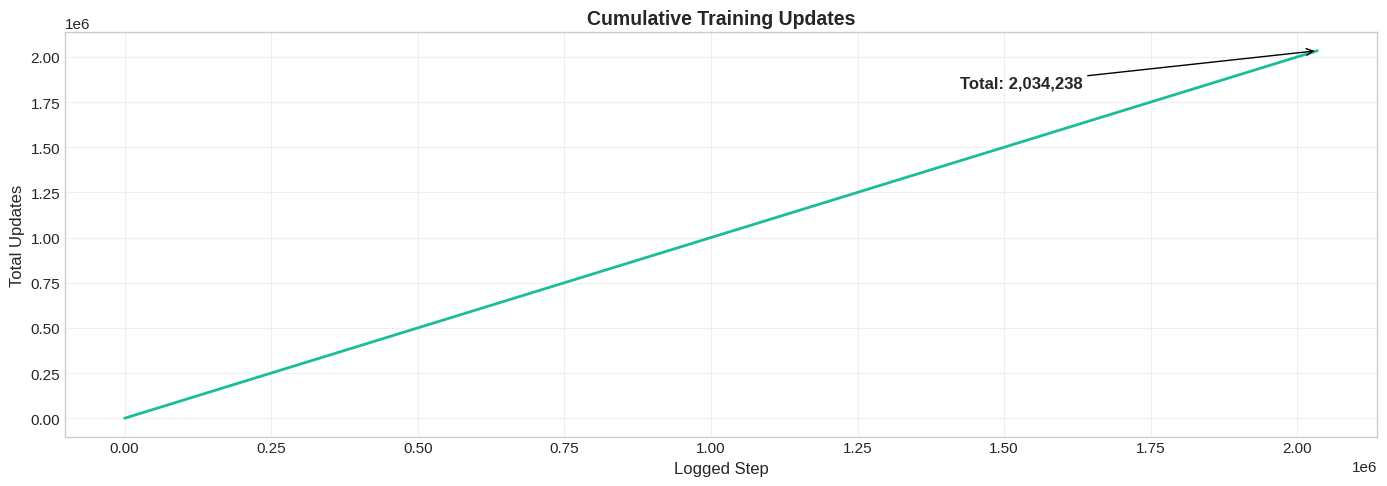

In [19]:
# Total Updates Over Time
if 'system/total_updates' in df.columns:
    update_data = df[['_step', 'system/total_updates']].dropna()
    
    plt.figure(figsize=(14, 5))
    plt.plot(update_data['_step'], update_data['system/total_updates'], 
             linewidth=2, color='#1abc9c')
    
    plt.xlabel('Logged Step', fontsize=12)
    plt.ylabel('Total Updates', fontsize=12)
    plt.title('Cumulative Training Updates', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Annotate final count
    final_updates = update_data['system/total_updates'].iloc[-1]
    plt.annotate(f'Total: {int(final_updates):,}', 
                 xy=(update_data['_step'].iloc[-1], final_updates),
                 xytext=(update_data['_step'].iloc[-1] * 0.7, final_updates * 0.9),
                 fontsize=12, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='black'))
    
    plt.tight_layout()
    plt.show()
else:
    print("system/total_updates not found in data.")

**Observation:** Total updates tracks the cumulative number of gradient updates. A linear relationship with step count indicates consistent training speed. Non-linear growth may indicate varying episode lengths or changing batch sizes. This metric helps estimate total compute used.

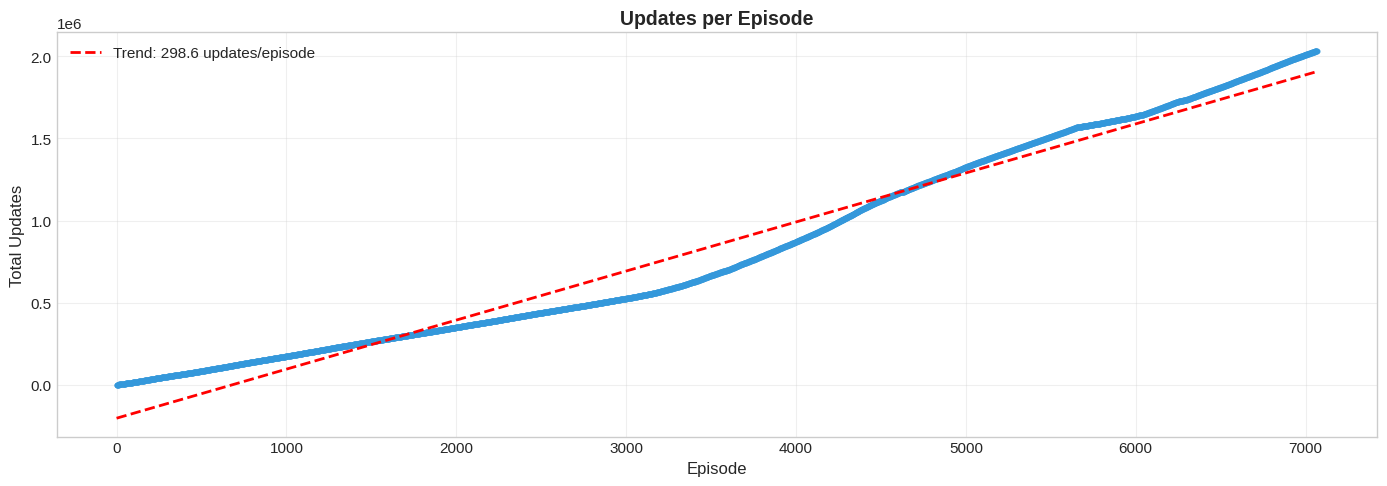

In [20]:
# Episodes vs Updates Relationship
if 'training/episode' in df.columns and 'system/total_updates' in df.columns:
    data = df[['training/episode', 'system/total_updates']].dropna()
    
    plt.figure(figsize=(14, 5))
    plt.scatter(data['training/episode'], data['system/total_updates'], 
                alpha=0.5, s=10, color='#3498db')
    
    # Fit linear trend
    if len(data) > 2:
        z = np.polyfit(data['training/episode'], data['system/total_updates'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(data['training/episode'].min(), data['training/episode'].max(), 100)
        plt.plot(x_line, p(x_line), 'r--', linewidth=2, 
                 label=f'Trend: {z[0]:.1f} updates/episode')
    
    plt.xlabel('Episode', fontsize=12)
    plt.ylabel('Total Updates', fontsize=12)
    plt.title('Updates per Episode', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Required columns not found for this plot.")

**Observation:** The relationship between episodes and updates reveals the average number of updates per episode. In A2C with n-step returns, longer episodes produce more updates. The slope indicates average episode length in terms of n-step batches.

---
## 7. Summary Statistics

In [21]:
# Training Summary
print("=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)

# Run info
print(f"\nRun: {run.name}")
print(f"State: {run.state}")
print(f"Total logged steps: {len(df)}")

# Training metrics
if 'training/episode_reward' in df.columns:
    rewards = df['training/episode_reward'].dropna()
    print(f"\nReward Statistics:")
    print(f"  Episodes: {len(rewards)}")
    print(f"  Mean reward: {rewards.mean():.2f}")
    print(f"  Max reward: {rewards.max():.2f}")
    print(f"  Min reward: {rewards.min():.2f}")
    print(f"  Final mean (100): {rewards.tail(100).mean():.2f}")

if 'training/mean_reward_100' in df.columns:
    mean_rewards = df['training/mean_reward_100'].dropna()
    print(f"\nMean Reward (100 ep):")
    print(f"  Final: {mean_rewards.iloc[-1]:.2f}")
    print(f"  Peak: {mean_rewards.max():.2f}")

# Check if solved
if 'solved_at_episode' in df.columns:
    solved = df['solved_at_episode'].dropna()
    if len(solved) > 0:
        print(f"\nEnvironment SOLVED at episode: {int(solved.iloc[0])}")

# Loss statistics
if 'losses/total_loss' in df.columns:
    losses = df['losses/total_loss'].dropna()
    print(f"\nLoss Statistics:")
    print(f"  Initial total loss: {losses.iloc[:100].mean():.4f}")
    print(f"  Final total loss: {losses.tail(100).mean():.4f}")

# System stats
if 'system/total_updates' in df.columns:
    updates = df['system/total_updates'].dropna()
    print(f"\nSystem:")
    print(f"  Total updates: {int(updates.iloc[-1]):,}")

print("\n" + "=" * 60)

TRAINING SUMMARY

Run: pong_cnn_a2c_basic
State: finished
Total logged steps: 11129

Reward Statistics:
  Episodes: 7068
  Mean reward: -7.81
  Max reward: 21.00
  Min reward: -21.00
  Final mean (100): 19.51

Mean Reward (100 ep):
  Final: 19.51
  Peak: 19.51

Environment SOLVED at episode: 7067

Loss Statistics:
  Initial total loss: 0.0783
  Final total loss: -0.0297

System:
  Total updates: 2,034,238



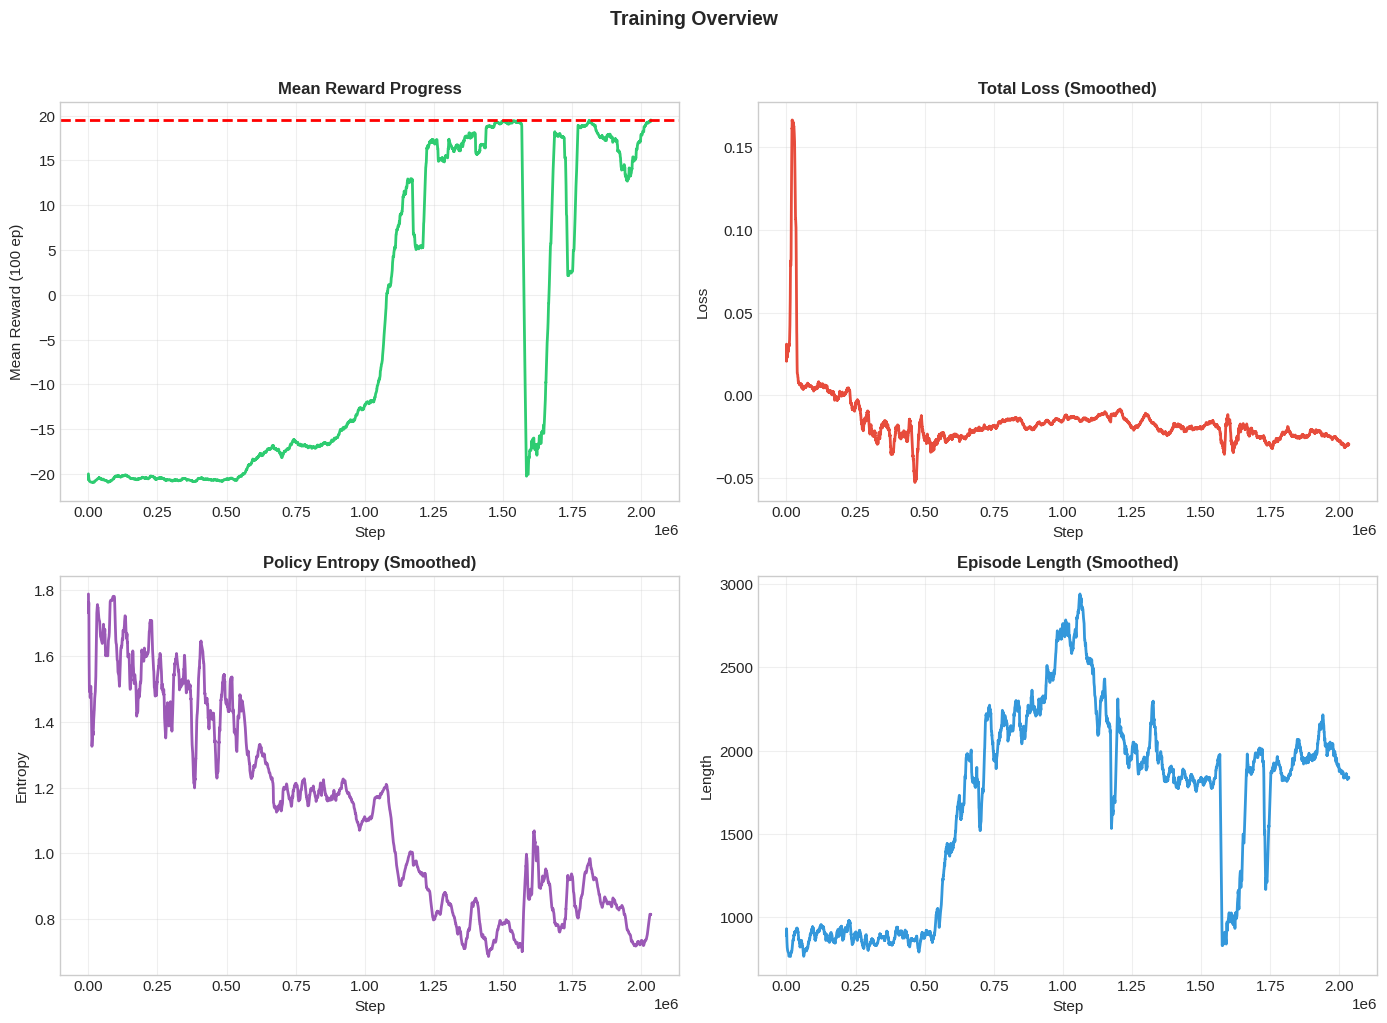

In [22]:
# Final Summary Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Reward progress
if 'training/mean_reward_100' in df.columns:
    data = df[['_step', 'training/mean_reward_100']].dropna()
    axes[0, 0].plot(data['_step'], data['training/mean_reward_100'], color='#2ecc71', linewidth=2)
    axes[0, 0].axhline(y=19.5, color='red', linestyle='--', linewidth=2)
    axes[0, 0].set_title('Mean Reward Progress', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Step')
    axes[0, 0].set_ylabel('Mean Reward (100 ep)')
    axes[0, 0].grid(True, alpha=0.3)

# 2. Total loss
if 'losses/total_loss' in df.columns:
    data = df[['_step', 'losses/total_loss']].dropna()
    if len(data) > 100:
        smoothed = data['losses/total_loss'].rolling(window=100, min_periods=1).mean()
        axes[0, 1].plot(data['_step'], smoothed, color='#e74c3c', linewidth=2)
    axes[0, 1].set_title('Total Loss (Smoothed)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Step')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].grid(True, alpha=0.3)

# 3. Entropy
if 'losses/entropy_loss' in df.columns:
    data = df[['_step', 'losses/entropy_loss']].dropna()
    entropy = -data['losses/entropy_loss']
    if len(data) > 100:
        smoothed = entropy.rolling(window=100, min_periods=1).mean()
        axes[1, 0].plot(data['_step'], smoothed, color='#9b59b6', linewidth=2)
    axes[1, 0].set_title('Policy Entropy (Smoothed)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Step')
    axes[1, 0].set_ylabel('Entropy')
    axes[1, 0].grid(True, alpha=0.3)

# 4. Episode length
if 'training/episode_length' in df.columns:
    data = df[['_step', 'training/episode_length']].dropna()
    if len(data) > 50:
        smoothed = data['training/episode_length'].rolling(window=50, min_periods=1).mean()
        axes[1, 1].plot(data['_step'], smoothed, color='#3498db', linewidth=2)
    axes[1, 1].set_title('Episode Length (Smoothed)', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Step')
    axes[1, 1].set_ylabel('Length')
    axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Training Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Final Observations:** This summary provides a holistic view of the training run. Key indicators of successful training include:
- Steadily increasing mean reward approaching or exceeding the target
- Decreasing total loss over time
- Entropy that decreases but doesn't collapse to zero
- Stable episode lengths indicating consistent gameplay

Areas for potential improvement can be identified by examining which metrics show concerning patterns (e.g., loss spikes, entropy collapse, gradient explosions).